# Make plots for paper

In [2]:
import jax.numpy as jnp
import jax.scipy as js
import numpy as np
import matplotlib.pyplot as plt
from chainconsumer import ChainConsumer, Chain, Truth, PlotConfig, ChainConfig, statistics
import healpy as hp
import dill

In [3]:
# load run
run_fn = 'run6'

# load PTA
with open(f'runs/{run_fn}/pta.pkl', 'rb') as f:
    pta = dill.load(f)

# load samples
with open(f'runs/{run_fn}/samples.pkl', 'rb') as f:
    samples = dill.load(f)

In [64]:
# # save power law samples for comparison with free spectral
# power_law_samples = samples.samples[10_000::2, pta.gwb_ndxs]
# np.save('power_law_samples.npy', power_law_samples)

In [79]:
ndxs = np.vstack((pta.psr_dist_ndxs, pta.psr_phase_ndxs)).T.flatten()[:10]
new_labels = [r'$L_1$', r'$\Phi_1$',
              r'$L_2$', r'$\Phi_2$',
              r'$L_3$', r'$\Phi_3$',
              r'$L_4$', r'$\Phi_4$',
              r'$L_5$', r'$\Phi_5$']

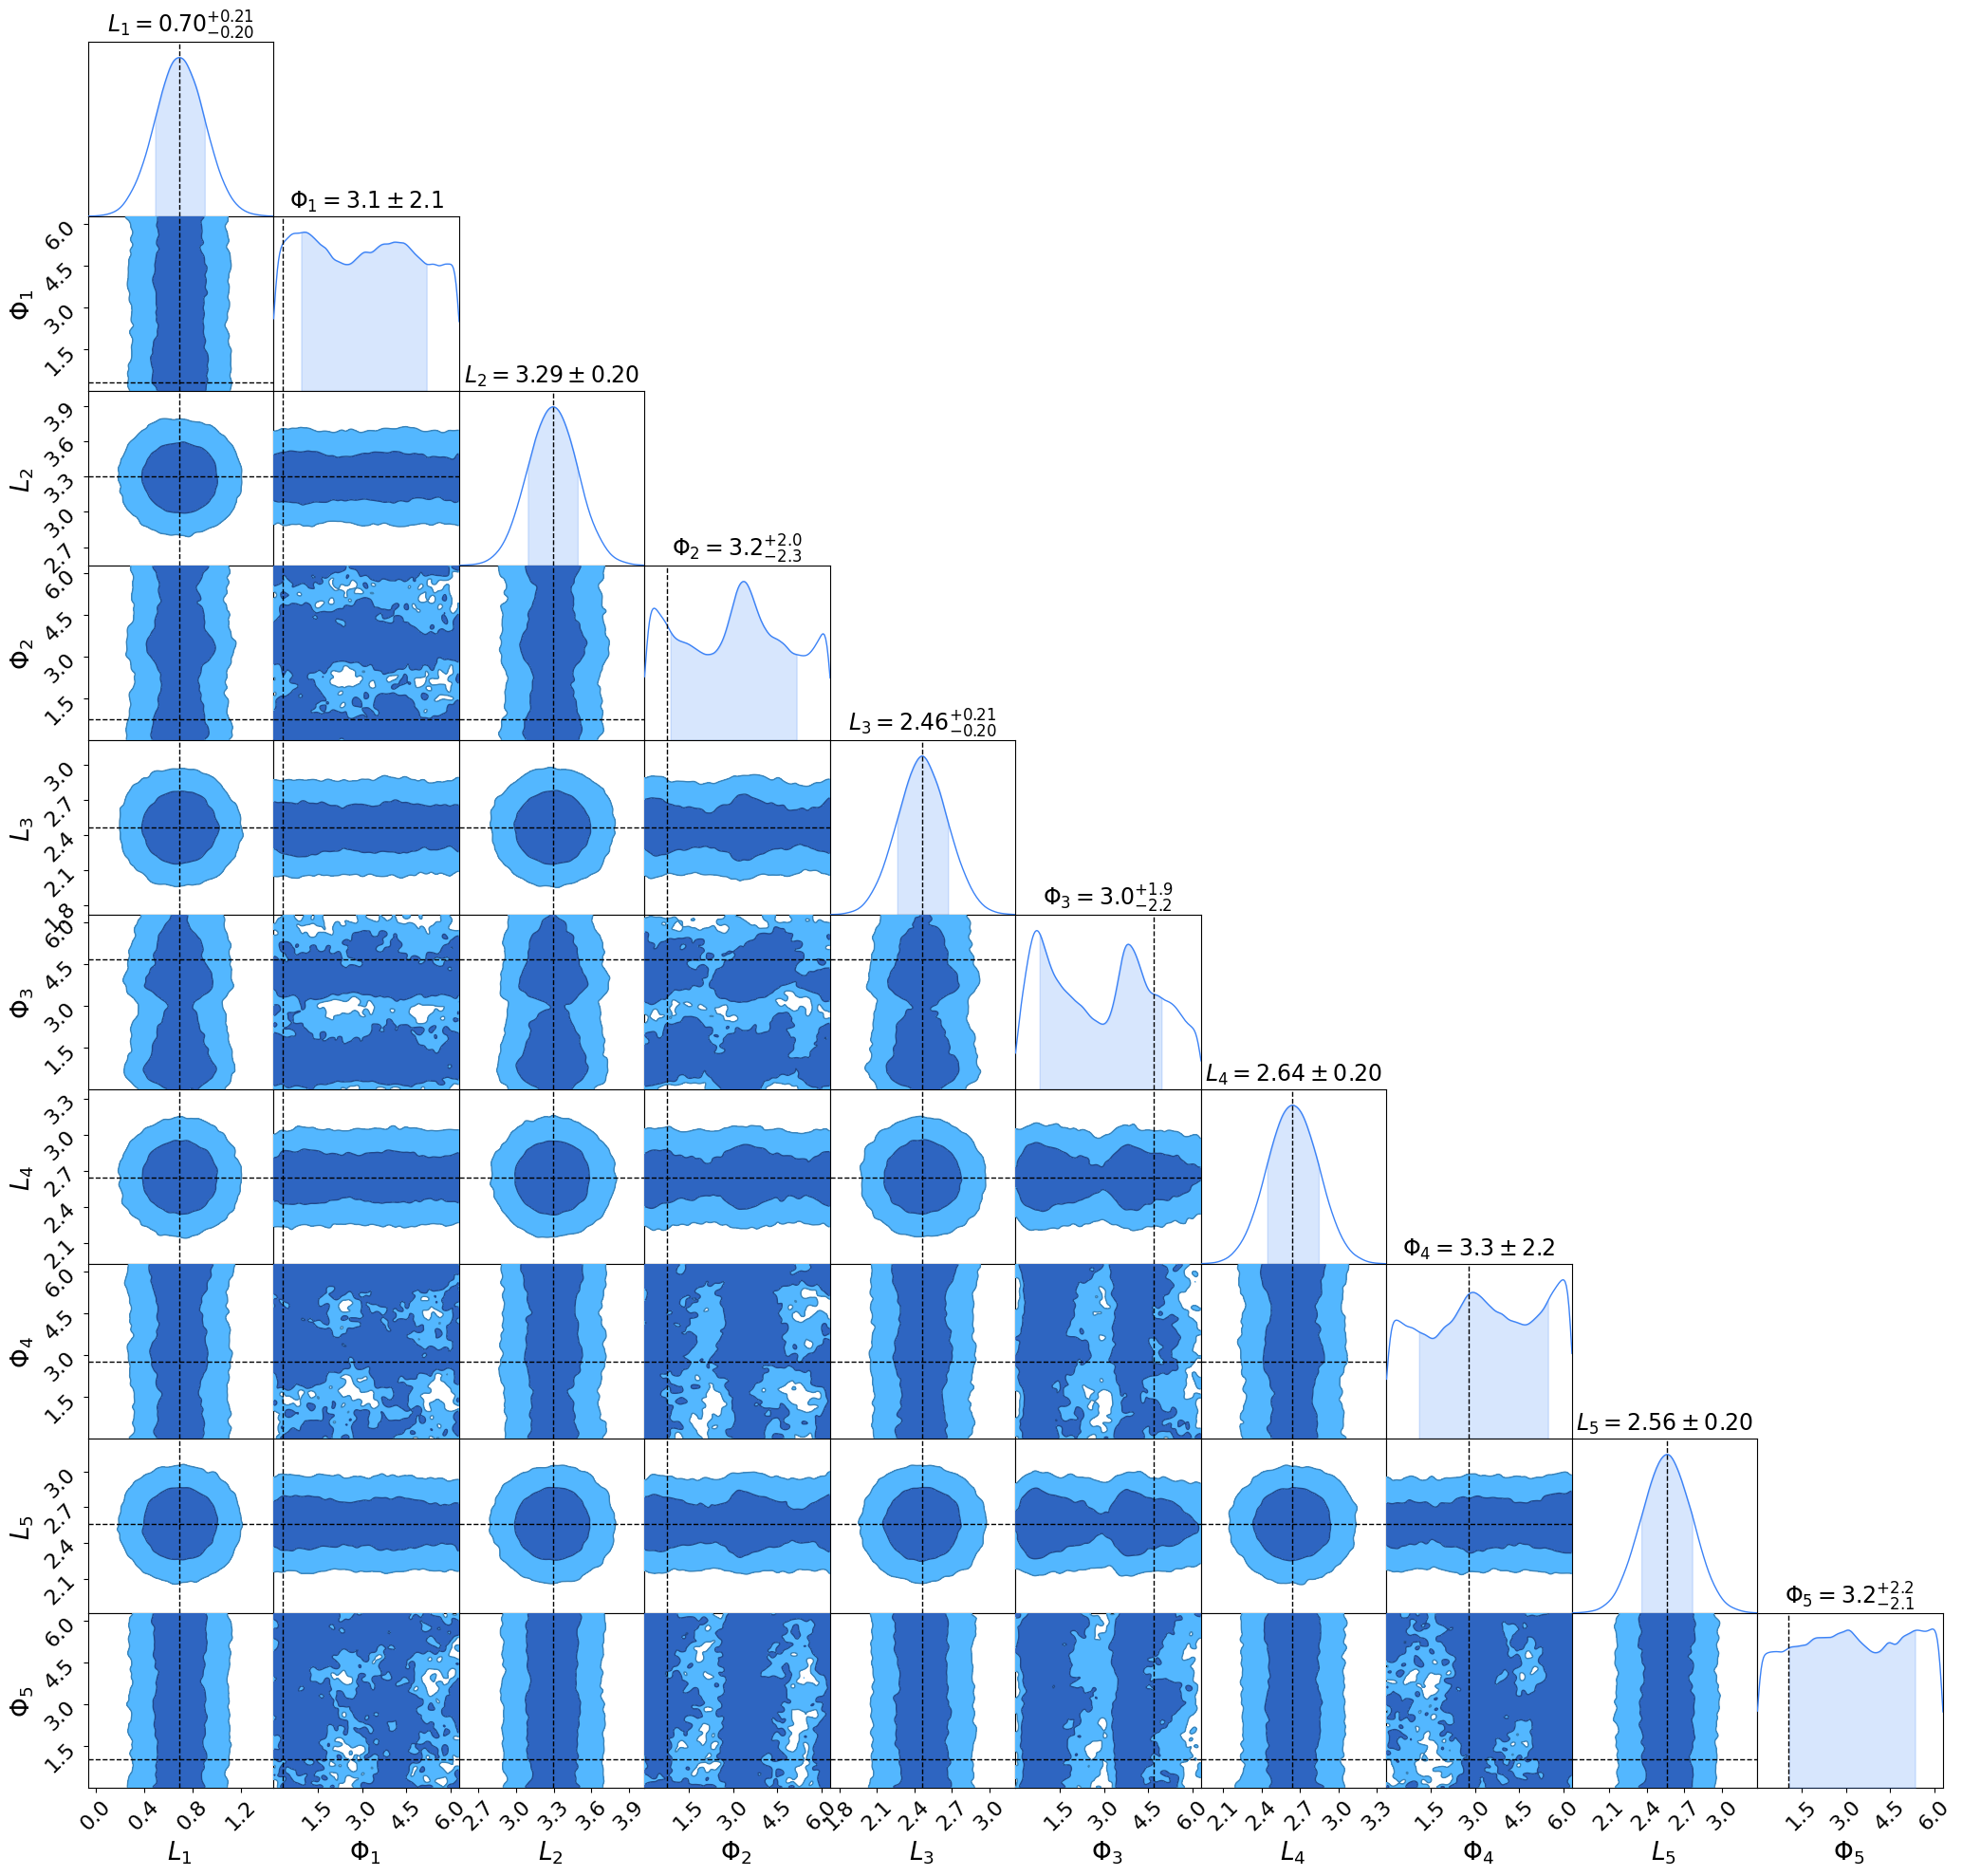

In [80]:
# ndxs = np.concatenate((pta.gwb_ndxs,
#                        pta.rn_ndxs.reshape((pta.Np, 2))[np.r_[6, 16]].flatten(),
#                        pta.a_ndxs.reshape((pta.Np, pta.Na))[6, np.r_[:2, -3:-2]]))
# ndxs = pta.cw_ndxs

# samples.corner_plt(param_ndxs=ndxs, burnin=10_000, thin=2)
cc = ChainConsumer()
# cc.add_chain(Chain(samples=samples.samples_df.iloc[10_000::2, ndxs], name='HMC'))
# cc.add_truth(Truth(location={name: val for name, val in zip(pta.x_labels, pta.x_inj)}))
new_df = samples.samples_df.iloc[10_000::2, ndxs].rename(columns={old: new for old, new in zip(pta.x_labels[ndxs], new_labels)}, inplace=False)
cc.add_chain(Chain(samples=new_df, name='HMC'))
cc.add_truth(Truth(location={name: val for name, val in zip(new_labels, pta.x_inj[ndxs])}))
cc.set_plot_config(PlotConfig(label_font_size=19, summary_font_size=17, tick_font_size=16))
cc.set_override(ChainConfig(statistics=statistics.SummaryStatistic.CUMULATIVE, bar_shade=True))
fig = cc.plotter.plot()

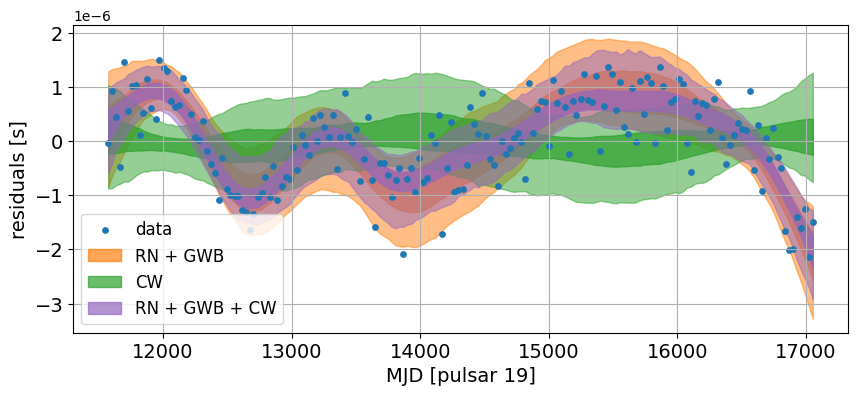

In [76]:
# Bayesogram
# psr_ndx = 0
# for psr_ndx in np.arange(pta.Np):
for psr_ndx in np.arange(18, 19):
    fair_draw_ndxs = np.random.choice(samples.samples.shape[0], (1000,))

    # percentile layers for plotting densities of samples
    # percentile_layers = [0.15, 2.5, 16.]
    percentile_layers = [2.5, 16.]
    alphas = [0.5, 0.7]

    # plot data, samples, and injected signals
    plt.figure(figsize=(10, 4))
    plt.scatter([], [], color='C0', s=15, label='data')

    # Bayesogram for RN + GWB
    if pta.model_rn or pta.model_gwb:
        rn_gwb_signals = np.array([pta.Rs[psr_ndx] @ pta.Fs[psr_ndx] @ samples.samples[ndx, pta.a_ndxs].reshape((pta.Np, pta.Na))[psr_ndx]
                                for ndx in fair_draw_ndxs])
        for percentile, alpha in zip(percentile_layers, alphas):
            if percentile != percentile_layers[-1]:
                plt.fill_between(pta.MJDs[psr_ndx], np.percentile(rn_gwb_signals, percentile, axis=0),
                                np.percentile(rn_gwb_signals, 100. - percentile, axis=0),
                                color='C1', alpha=alpha)
            else:
                plt.fill_between(pta.MJDs[psr_ndx], np.percentile(rn_gwb_signals, percentile, axis=0),
                                np.percentile(rn_gwb_signals, 100. - percentile, axis=0),
                                color='C1', alpha=alpha, label='RN + GWB')
        rn_gwb_residuals_inj = pta.Rs[psr_ndx] @ pta.Fs[psr_ndx] @ pta.a_inj.reshape((pta.Np, pta.Na))[psr_ndx]
        # plt.plot(pta.MJDs[psr_ndx], pta.Rs[psr_ndx] @ rn_gwb_residuals_inj, color='k')

    # Bayesogram for CW
    if pta.model_cw:
        a_cws = np.array([pta.get_CW_coefficients(samples.samples[ndx, pta.cw_psr_ndxs])[psr_ndx]
                    for ndx in fair_draw_ndxs])
        cw_signals = np.array([pta.Rs[psr_ndx] @ pta.Fs_cw[psr_ndx] @ a_cw for a_cw in a_cws])
        for percentile, alpha in zip(percentile_layers, alphas):
            if percentile != percentile_layers[-1]:
                plt.fill_between(pta.MJDs[psr_ndx], np.percentile(cw_signals, percentile, axis=0),
                                np.percentile(cw_signals, 100. - percentile, axis=0),
                                color='C2', alpha=alpha)
            else:
                plt.fill_between(pta.MJDs[psr_ndx], np.percentile(cw_signals, percentile, axis=0),
                                np.percentile(cw_signals, 100. - percentile, axis=0),
                                color='C2', alpha=alpha, label='CW')
        cw_signal_inj = pta.Rs[psr_ndx] @ pta.cw_delay_toa_input(pta.x_inj[pta.cw_psr_ndxs], pta.toas)[psr_ndx]
        # plt.plot(pta.MJDs[psr_ndx], pta.Rs[psr_ndx] @ cw_signal_inj, color='white')

    # Bayesogram for RN + GWB + CW
    if pta.model_rn and pta.model_gwb and pta.model_cw:
        signals = cw_signals + rn_gwb_signals
        for percentile, alpha in zip(percentile_layers, alphas):
            if percentile != percentile_layers[-1]:
                plt.fill_between(pta.MJDs[psr_ndx], np.percentile(signals, percentile, axis=0),
                                np.percentile(signals, 100. - percentile, axis=0),
                                color='C4', alpha=alpha)
            else:
                plt.fill_between(pta.MJDs[psr_ndx], np.percentile(signals, percentile, axis=0),
                                np.percentile(signals, 100. - percentile, axis=0),
                                color='C4', alpha=alpha, label='RN + GWB + CW')
        # plt.plot(pta.MJDs[psr_ndx], rn_gwb_residuals_inj + cw_signal_inj, color='purple', label='RN + GWB + CW injection')



    plt.scatter(pta.MJDs[psr_ndx], pta.Rs[psr_ndx] @ pta.residuals[psr_ndx], color='C0', s=15)
    plt.xlabel(f'MJD [pulsar {psr_ndx + 1}]', fontsize=14)
    plt.ylabel('residuals [s]', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

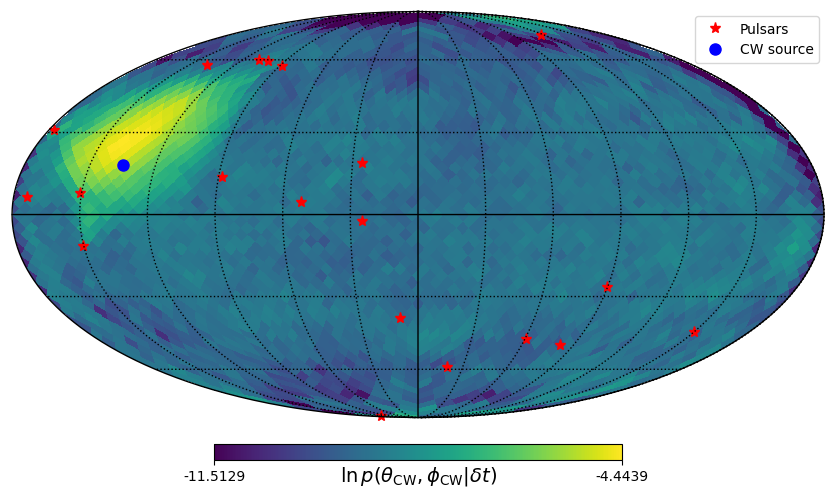

In [5]:
# sky map

# rotate sky map so bounds on azimuthal angle phi is on edges
phi_shift = np.pi

# pulsar positions
theta_psr = np.arccos(pta.psr_pos[:, 2])  # z = cos(theta)
phi_psr = np.mod(np.arctan2(pta.psr_pos[:, 1], pta.psr_pos[:, 0]), 2 * np.pi)

# resolution
nside = 16
npix = hp.nside2npix(nside)

# convert CW sky samples to healpix pixel indices
cos_gwtheta_samples = samples.samples[:, pta.cw_ndxs][:,-3]
gwphi_samples = samples.samples[:, pta.cw_ndxs][:,-2]
pix_indices = hp.ang2pix(nside, np.arccos(cos_gwtheta_samples), gwphi_samples + phi_shift)

# count number of samples in each pixel
density_map = np.bincount(pix_indices, minlength=npix).astype(float)

# normalize to show as a probability density
density_map /= np.sum(density_map)

# plot sky map with posterior density
hp.mollview(np.log(density_map + 1.e-5),
            title='',
            unit=r'$\ln p(\theta_\text{CW}, \phi_\text{CW} | \delta t)$',
            cmap='viridis')

# overlay pulsar positions
hp.projplot(theta_psr, phi_psr + phi_shift, 'r*', markersize=8)
hp.projplot([], [], 'r*', markersize=8, label='Pulsars')

# overlay injected GW source position
cos_gwtheta_inj = pta.x_inj[pta.cw_ndxs][-3]
gwphi_inj = pta.x_inj[pta.cw_ndxs][-2]
hp.projplot(np.arccos(cos_gwtheta_inj), gwphi_inj + phi_shift, 'bo', markersize=8, label='CW source')

hp.graticule()
plt.legend()
plt.show()

In [6]:
rn_phi = jnp.diag(pta.vectorized_get_rho_diag(pta.x_inj[pta.rn_ndxs].reshape((pta.Np, 2))).flatten())
gwb_phi = jnp.kron(pta.alpha, jnp.diag(pta.get_rho_diag(pta.x_inj[pta.gwb_ndxs])))
phi = rn_phi + gwb_phi
F_full = js.linalg.block_diag(*pta.Fs)
N_full = js.linalg.block_diag(*pta.Ns)
C = N_full + F_full @ phi @ F_full.T
G_full = js.linalg.block_diag(*pta.Gs)
C_proj = G_full.T @ C @ G_full
cw_signal = pta.cw_delay_toa_input(pta.x_inj[pta.cw_psr_ndxs], pta.toas).flatten()
cw_signal_proj = G_full.T @ cw_signal
L_cov = jnp.linalg.cholesky(C_proj)
z = js.linalg.solve_triangular(L_cov, cw_signal_proj, lower=True)
SNR_sq = jnp.inner(z, z)
print(f'CW SNR = {jnp.sqrt(SNR_sq)}')

CW SNR = 13.718568801879883


In [12]:
Ws = jnp.array([F.T @ Ntinv @ F for F, Ntinv in zip(pta.Fs, pta.Ntinvs)])
Ws_tilde = jnp.array([F.T @ Ntinv @ F_cw for F, Ntinv, F_cw in zip(pta.Fs, pta.Ntinvs, pta.Fs_cw)])

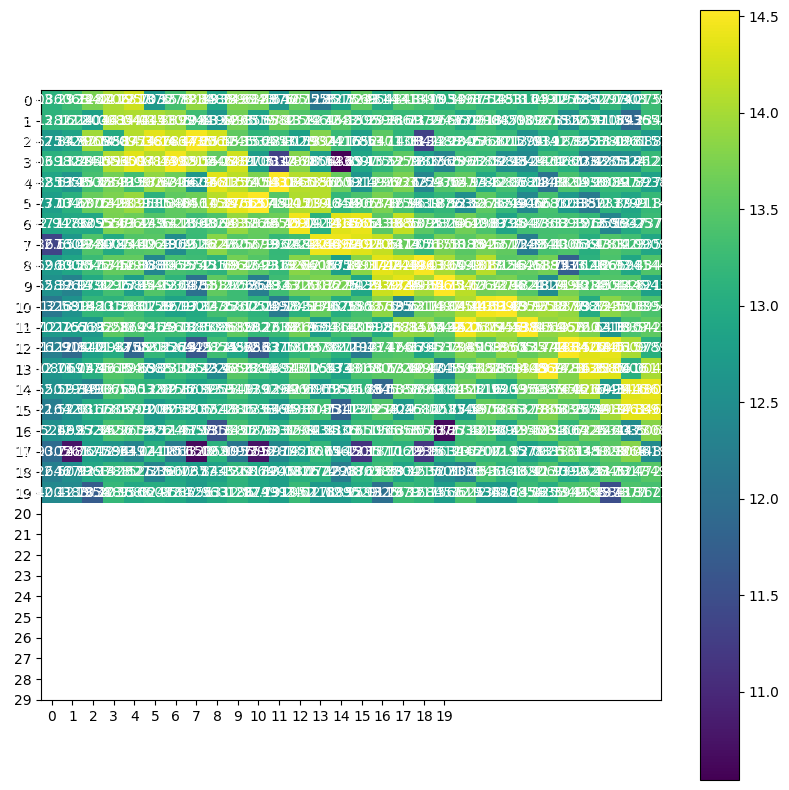

In [16]:
# W_mat = Ws[0]
W_mat = Ws_tilde[0]
plt.figure(figsize=(10, 10))
plt.imshow(jnp.log10(jnp.abs(W_mat)))
plt.colorbar()
# Show all ticks and label them with the respective list entries
plt.xticks(range(W_mat.shape[0]))
plt.yticks(range(W_mat.shape[1]))

# Loop over data dimensions and create text annotations.
for i in range(W_mat.shape[0]):
    for j in range(W_mat.shape[1]):
        text = plt.text(j, i, jnp.log10(jnp.abs(W_mat[i, j])),
                       ha="center", va="center", color="w")

plt.show()